<a href="https://colab.research.google.com/github/jenelaineDC/DSML-PROJECTS/blob/main/TikTok%20Claims/Tiktok_Claims_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### BACKGROUND:

As a data scientist on the TikTok analytics team, I am tasked with addressing the challenge of mitigating misinformation on the platform. Millions of videos are uploaded and viewed daily, and many are reported by users for potentially violating TikTok’s terms of service. Manually reviewing all reported content is infeasible, creating a critical need for data-driven solutions.

Analysis shows that videos in violation of platform rules are more likely to present a claim rather than an opinion. Accurately distinguishing between these categories allows TikTok to prioritize content that may require immediate moderation, thereby protecting users and ensuring platform integrity.

From an ethical perspective, misclassifying content carries implications for both user experience and safety. A false positive—misclassifying an opinion as a claim—may result in unnecessary human review but preserves platform safety. A false negative—misclassifying a claim as an opinion—poses a higher risk, as harmful content may go unchecked. Therefore, the model must be designed with ethical safeguards to minimize false negatives while maintaining fairness and transparency.

### PROJECT GOALS:

The objective of this project is to build a predictive model that classifies TikTok videos as either claims or opinions. Specifically, I aim to:

- Develop machine learning models that can accurately estimate the probability that a video presents a claim.
- Evaluate multiple algorithms (e.g., Random Forest, XGBoost) to determine the most effective approach.
- Prioritize evaluation metrics such as recall to minimize the risk of failing to flag potentially harmful content.
- Provide actionable insights to inform TikTok’s moderation strategies and support decision-making for content review prioritization

### SCOPE AND LIMITATIONS:
This project will:
- Use the existing TikTok dataset, focusing on the claim_status binary target variable.
- Perform feature engineering, including selection, extraction, and transformation, to improve model performance.
- Compare the performance of different classification models to identify the optimal approach.

This project will not:
- Collect additional data beyond the provided dataset.
- Replace human moderators; the model is intended to assist and prioritize content review.
- Deploy models into production; findings will guide future iterations and inform business decisions for content moderation.


#### SET-UP

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/DSML PROJECTS/Tiktok

/content/drive/MyDrive/DSML PROJECTS/Tiktok


In [ ]:
# for operational libraries
import pandas as pd
import numpy as np

# for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# This lets us see all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)

# for train test val split
from sklearn.model_selection import train_test_split, PredefinedSplit

# evaluation metrics
from sklearn.metrics import recall_score, precision_score, accuracy_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# import available models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# This is the function that helps plot feature importance
from xgboost import plot_importance

# # This module lets us save our models once we fit them.
import pickle
import joblib

### DATA DEVELOPMENT PROCESS

#### Data Source

This dataset is supplied as part of the Google Advanced Data Analytics Professional Certificate program courses on Coursera. It contains 19, 382 entries and 11 attributes listed below.

Data Card

| Variable | Description |
|---------|-------------|
| # | Unique row identifier |
| claim_status | Binary target variable indicating whether the video is a `claim` or an `opinion` |
| video_id | Unique identifier for each video |
| video_duration_sec | Duration of the video in seconds |
| video_transcription_text | Text transcription of the video content |
| verified_status | Indicates whether the author’s account is verified (`verified` / `not verified`) |
| author_ban_status | Indicates whether the author has been banned from the platform (`under review` / `active`) |
| video_view_count | Number of times the video has been viewed |
| video_like_count | Number of likes the video has received |
| video_share_count | Number of times the video has been shared |
| video_download_count | Number of times the video has been downloaded |
| video_comment_count | Number of comments on the video |


In [ ]:
df0 = pd.read_csv("tiktok_dataset.csv")

In [ ]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [ ]:
df0.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [ ]:
df0.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


#### Missing Values, Duplicates and Unnecessary Columns

In [ ]:
# Check for missing values
df0.isnull().sum()

,0
#,0
claim_status,298
video_id,0
video_duration_sec,0
video_transcription_text,298
verified_status,0
author_ban_status,0
video_view_count,298
video_like_count,298
video_share_count,298


In [ ]:
df0 = df0.dropna()

In [ ]:
df0.isnull().sum()

,0
#,0
claim_status,0
video_id,0
video_duration_sec,0
video_transcription_text,0
verified_status,0
author_ban_status,0
video_view_count,0
video_like_count,0
video_share_count,0


In [ ]:
df0 = df0.drop(columns=['#', 'video_id'])
df0.columns

Index(['claim_status', 'video_duration_sec', 'video_transcription_text',
       'verified_status', 'author_ban_status', 'video_view_count',
       'video_like_count', 'video_share_count', 'video_download_count',
       'video_comment_count'],
      dtype='object')

#### Outlier Detection

In [ ]:
num_col = ['video_duration_sec', 'video_view_count', 'video_like_count', 'video_share_count',
           'video_download_count', 'video_comment_count']

cat_col = ['claim_status', 'verified_status', 'author_ban_status']

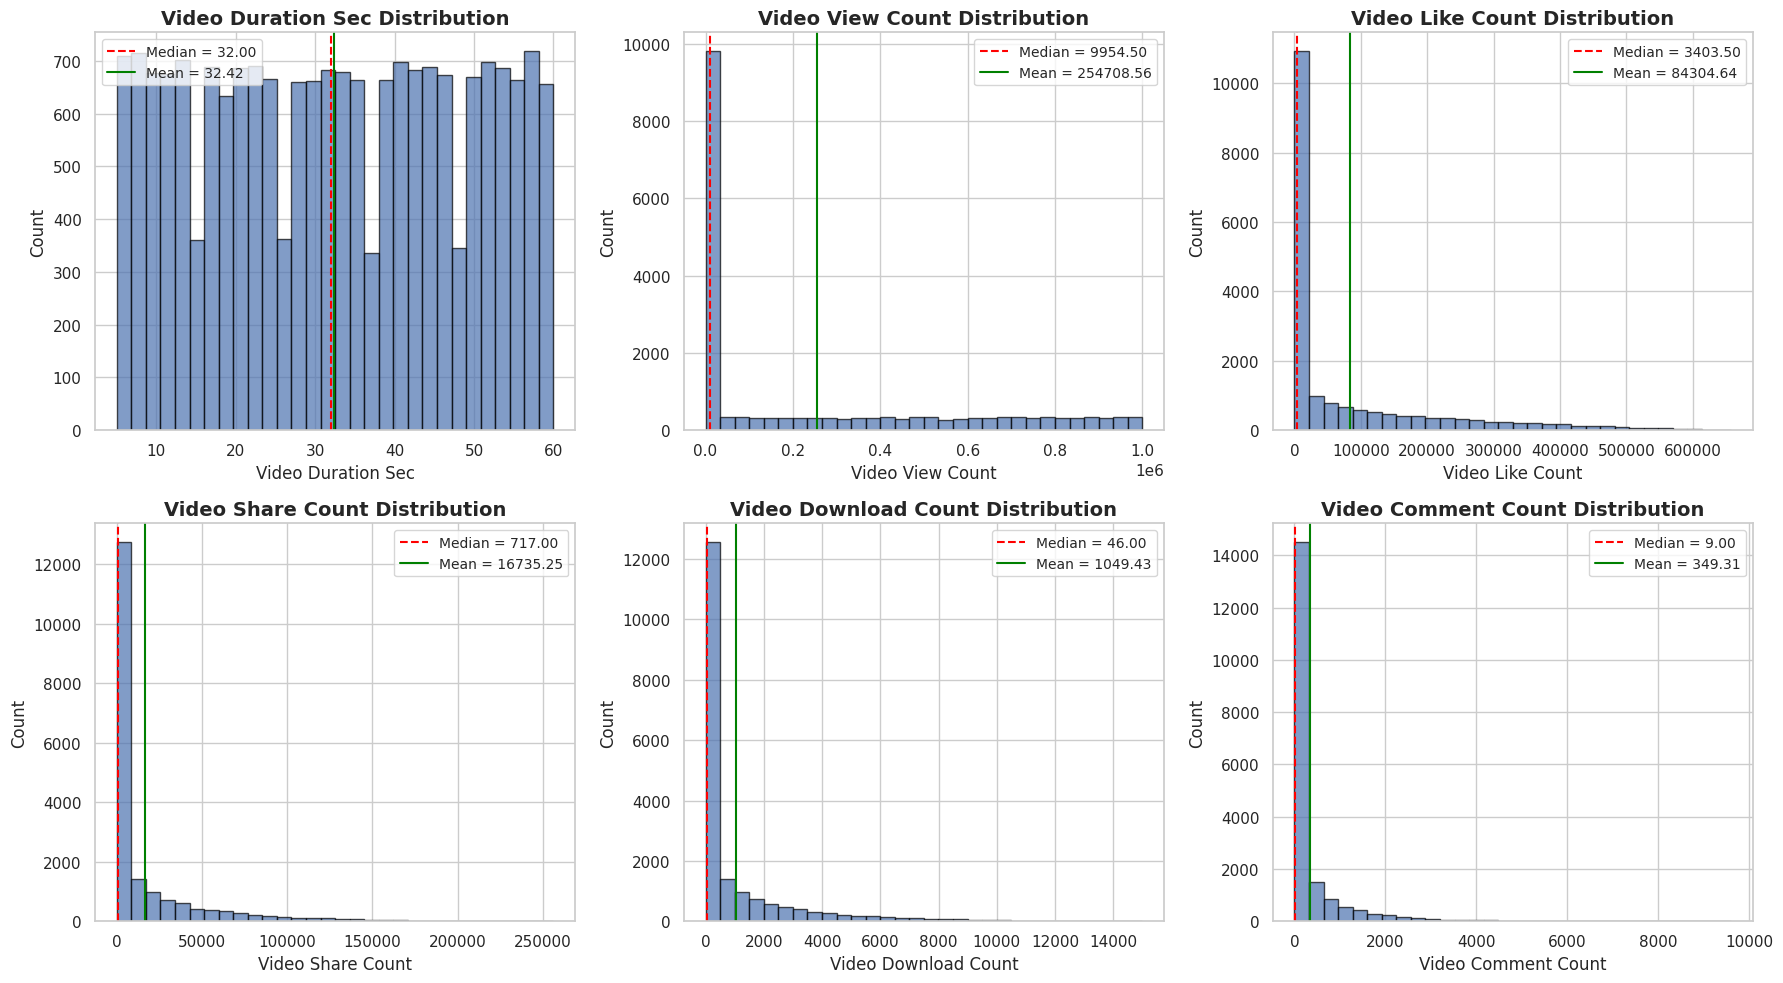

In [ ]:
sns.set(style="whitegrid")
palette_color = "#4C72B0"

# Create subplot grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

# Loop through numeric columns and plot histograms
for i, col in enumerate(num_col):
    axes[i].hist(df0[col], bins=30, color=palette_color, edgecolor='black', alpha=0.7)

    # Calculate median and mean
    median = df0[col].median()
    mean = df0[col].mean()

    # Add median line
    axes[i].axvline(median, color='red', linestyle='--', linewidth=1.5, label=f'Median = {median:.2f}')

    # Add mean line
    axes[i].axvline(mean, color='green', linestyle='-', linewidth=1.5, label=f'Mean = {mean:.2f}')

    # Titles and labels
    axes[i].set_title(f'{col.replace("_", " ").title()} Distribution', fontsize=14, weight='bold')
    axes[i].set_xlabel(col.replace("_", " ").title(), fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)

    # Show legend
    axes[i].legend(fontsize=10)

# Remove empty subplots if num_col < nrows*ncols
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

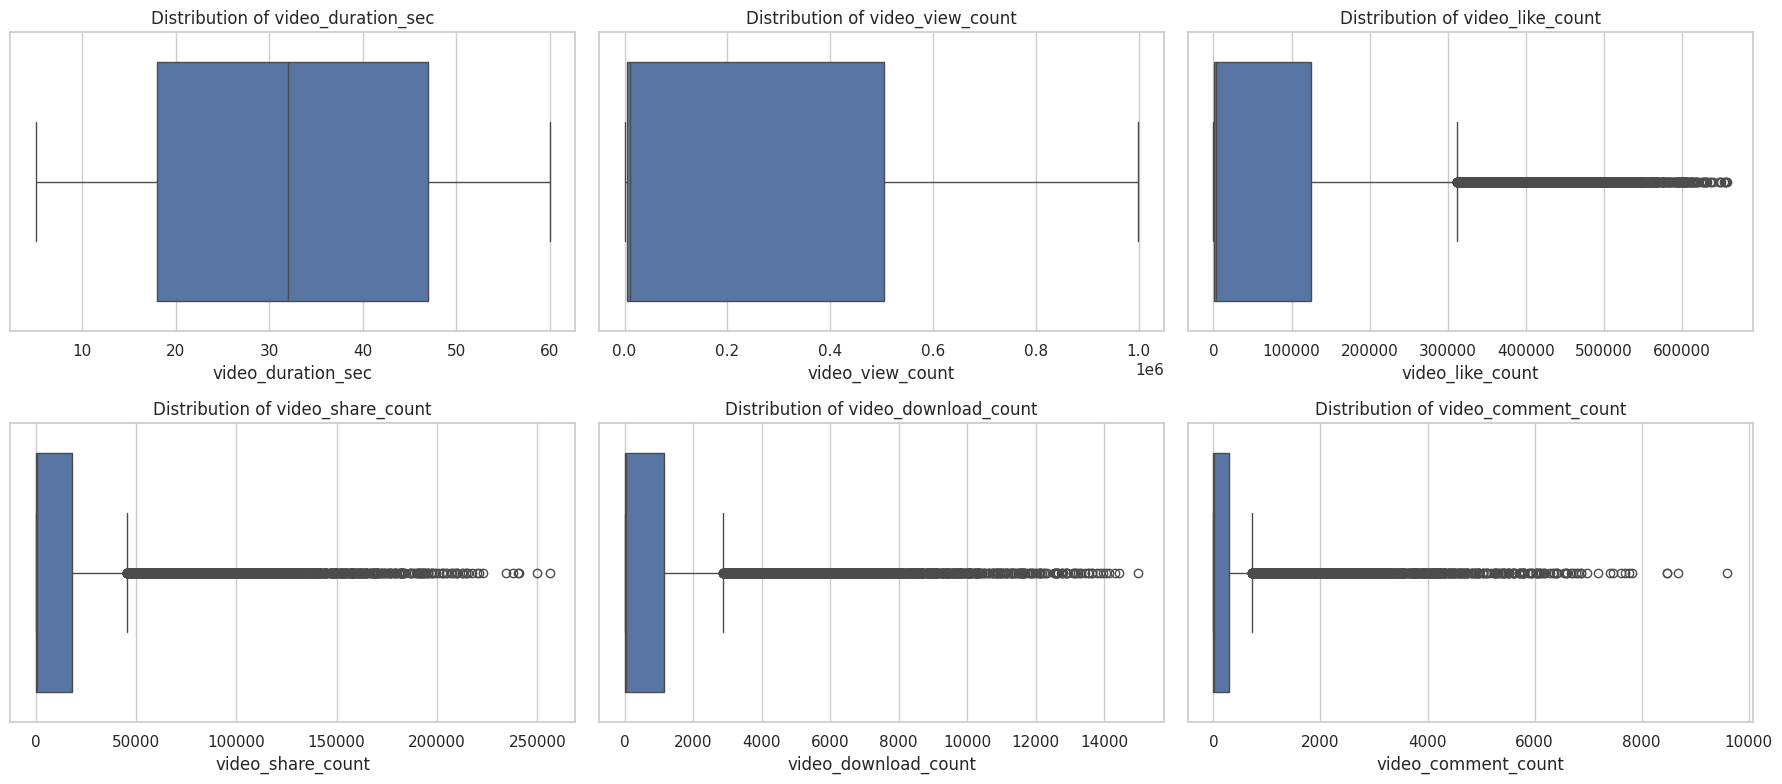

In [ ]:
# Create subplot grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 8))
axes = axes.flatten()

sns.set(style="whitegrid")

for i, col in enumerate(num_col):
    sns.boxplot(x=df0[col], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

# Remove empty subplots if num_col < rows*cols
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Feature Engineering

To improve the model’s ability to detect claim videos, I engineered several new features. Each feature is designed to enhance predictive performance while providing business-relevant insights into video engagement and content characteristics:

- **`likes_per_view`**: The ratio of likes to total views, measuring relative engagement and helping identify highly engaging content.  

- **`comments_per_view`**: The ratio of comments to views, capturing user interaction depth and signaling content that sparks discussion.  

- **`shares_per_view`**: The ratio of shares to views, indicating content virality and its potential to spread across the platform.  

- **`downloads_per_view`**: The ratio of downloads to views, highlighting content that users want to save, which can correlate with perceived importance or credibility.  

- **`engagement_score`**: Aggregates likes, comments, shares, and downloads per view to provide an overall engagement metric, serving as a single, interpretable feature for video impact.  

- **`text_sentiment`**: Sentiment polarity of the video transcription, capturing whether the content is positive, negative, or neutral, which can influence user perception and reporting behavior.  

- **`text_length`**: The number of characters in the video transcription, reflecting content complexity and potentially differentiating brief opinions from substantive claims.  

These features combine **behavioral engagement, content characteristics, and textual signals** to strengthen the model’s ability to prioritize claim videos for moderation, supporting TikTok’s goal of mitigating misinformation efficiently.



In [ ]:
# Create likes_per_view column
df0['likes_per_view'] = df0['video_like_count'] / df0['video_view_count']

# Create comments_per_view column
df0['comments_per_view'] = df0['video_comment_count'] / df0['video_view_count']

# Create shares_per_view column
df0['shares_per_view'] = df0['video_share_count'] / df0['video_view_count']

# Create shares_per_view column
df0['downloads_per_view'] = df0['video_download_count'] / df0['video_view_count']

df0['engagement_score'] = (
    df0['video_like_count'] +
    df0['video_comment_count'] +
    df0['video_share_count'] +
    df0['video_download_count']
) / df0['video_view_count']

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the VADER sentiment lexicon if not already
nltk.download('vader_lexicon')

# Instantiate the sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Create text_sentiment feature
df0['text_sentiment'] = df0['video_transcription_text'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
# Create text_length
df0['text_length'] = df0['video_transcription_text'].str.len()

In [ ]:
num_col = ['likes_per_view', 'comments_per_view', 'shares_per_view',
           'downloads_per_view', 'engagement_score',
           'text_sentiment', 'text_length']

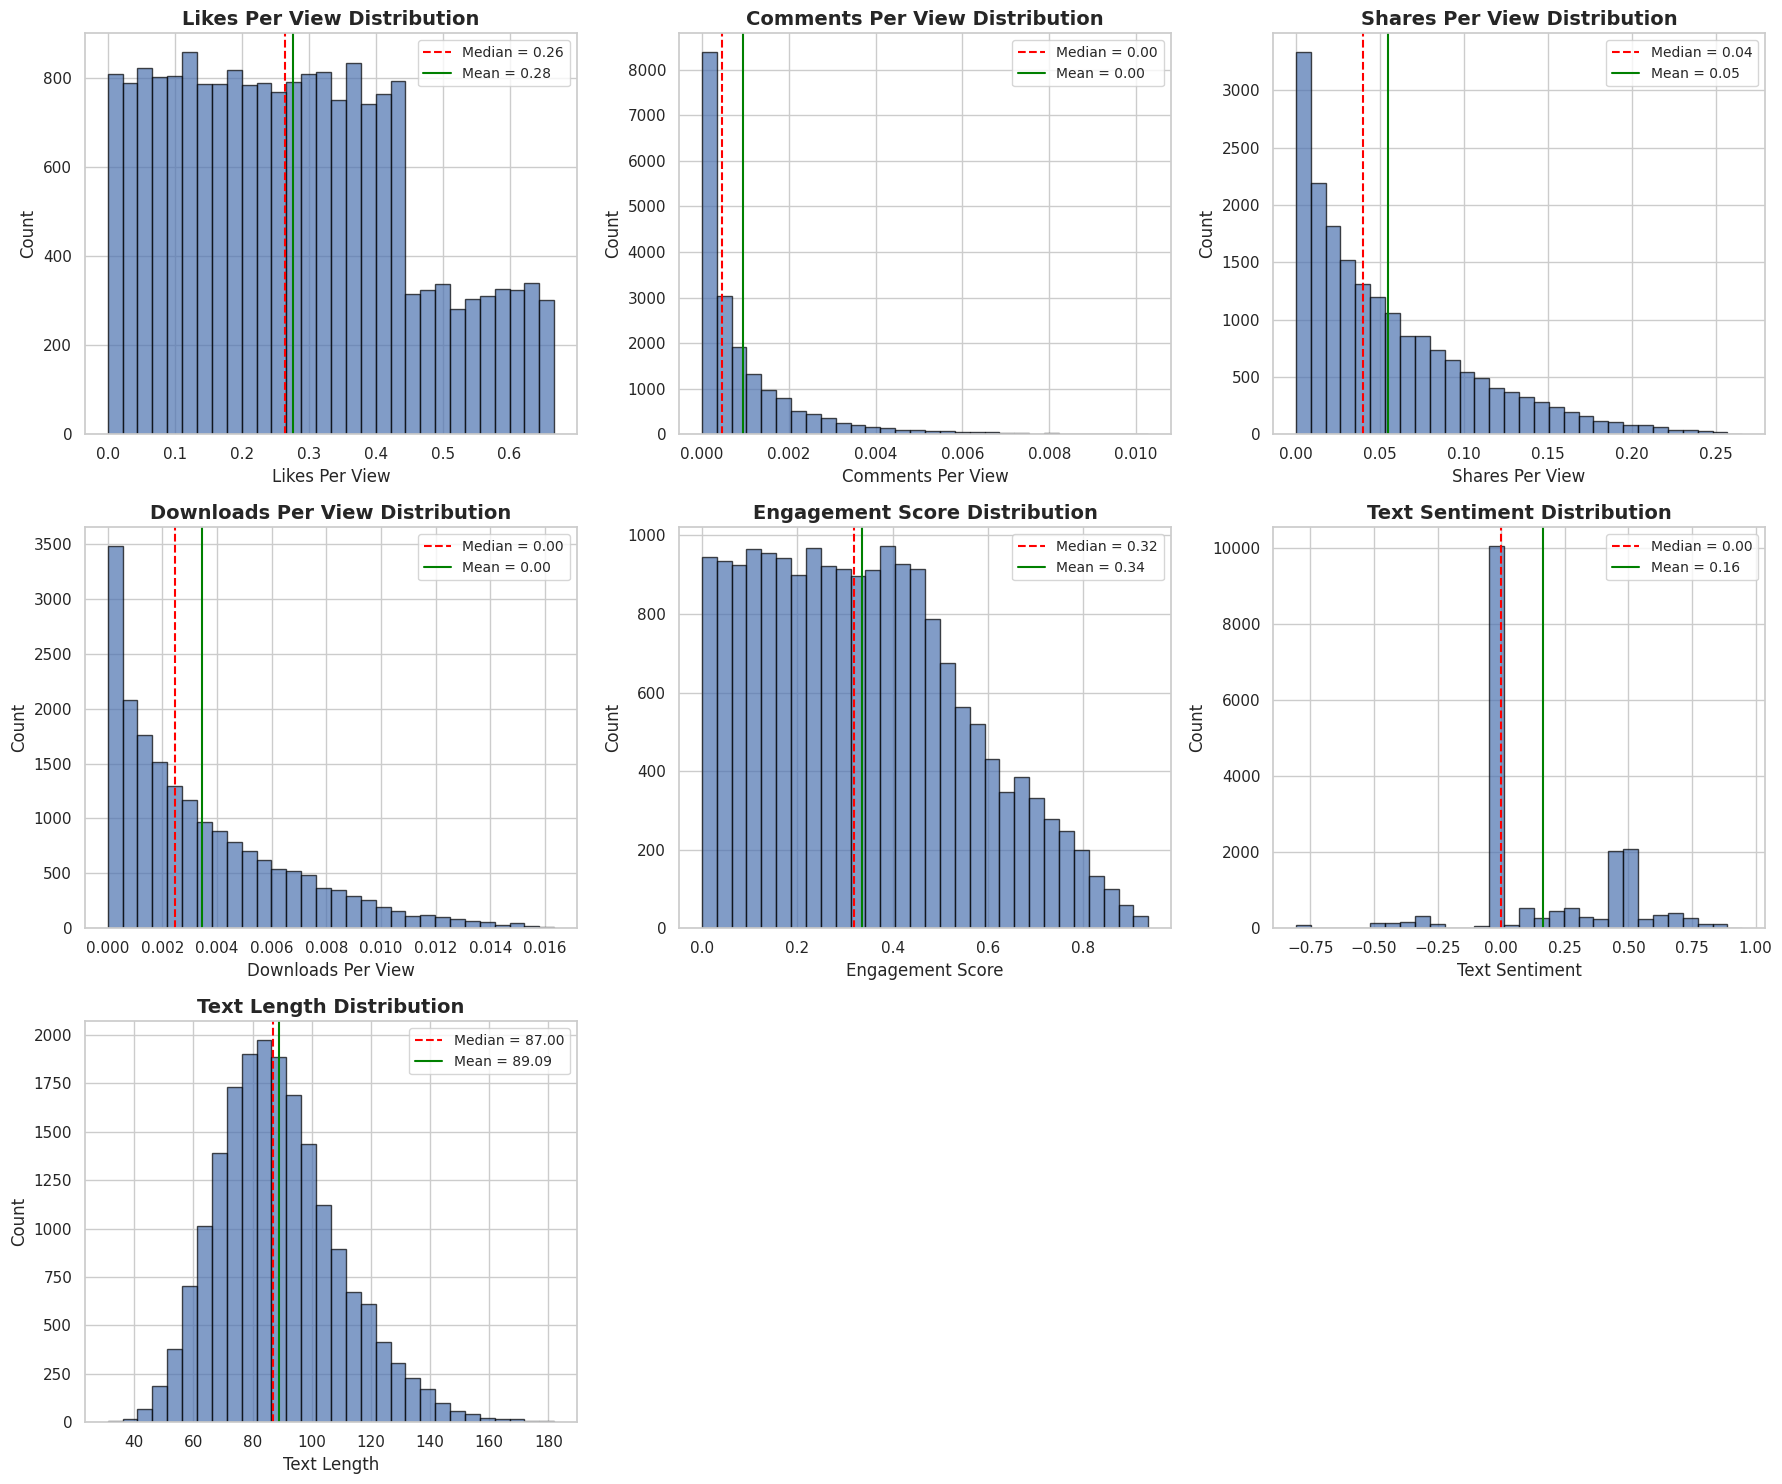

In [ ]:
sns.set(style="whitegrid")
palette_color = "#4C72B0"

# Create subplot grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

# Loop through numeric columns and plot histograms
for i, col in enumerate(num_col):
    axes[i].hist(df0[col], bins=30, color=palette_color, edgecolor='black', alpha=0.7)

    # Calculate median and mean
    median = df0[col].median()
    mean = df0[col].mean()

    # Add median line
    axes[i].axvline(median, color='red', linestyle='--', linewidth=1.5, label=f'Median = {median:.2f}')

    # Add mean line
    axes[i].axvline(mean, color='green', linestyle='-', linewidth=1.5, label=f'Mean = {mean:.2f}')

    # Titles and labels
    axes[i].set_title(f'{col.replace("_", " ").title()} Distribution', fontsize=14, weight='bold')
    axes[i].set_xlabel(col.replace("_", " ").title(), fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)

    # Show legend
    axes[i].legend(fontsize=10)

# Remove empty subplots if num_col < nrows*ncols
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


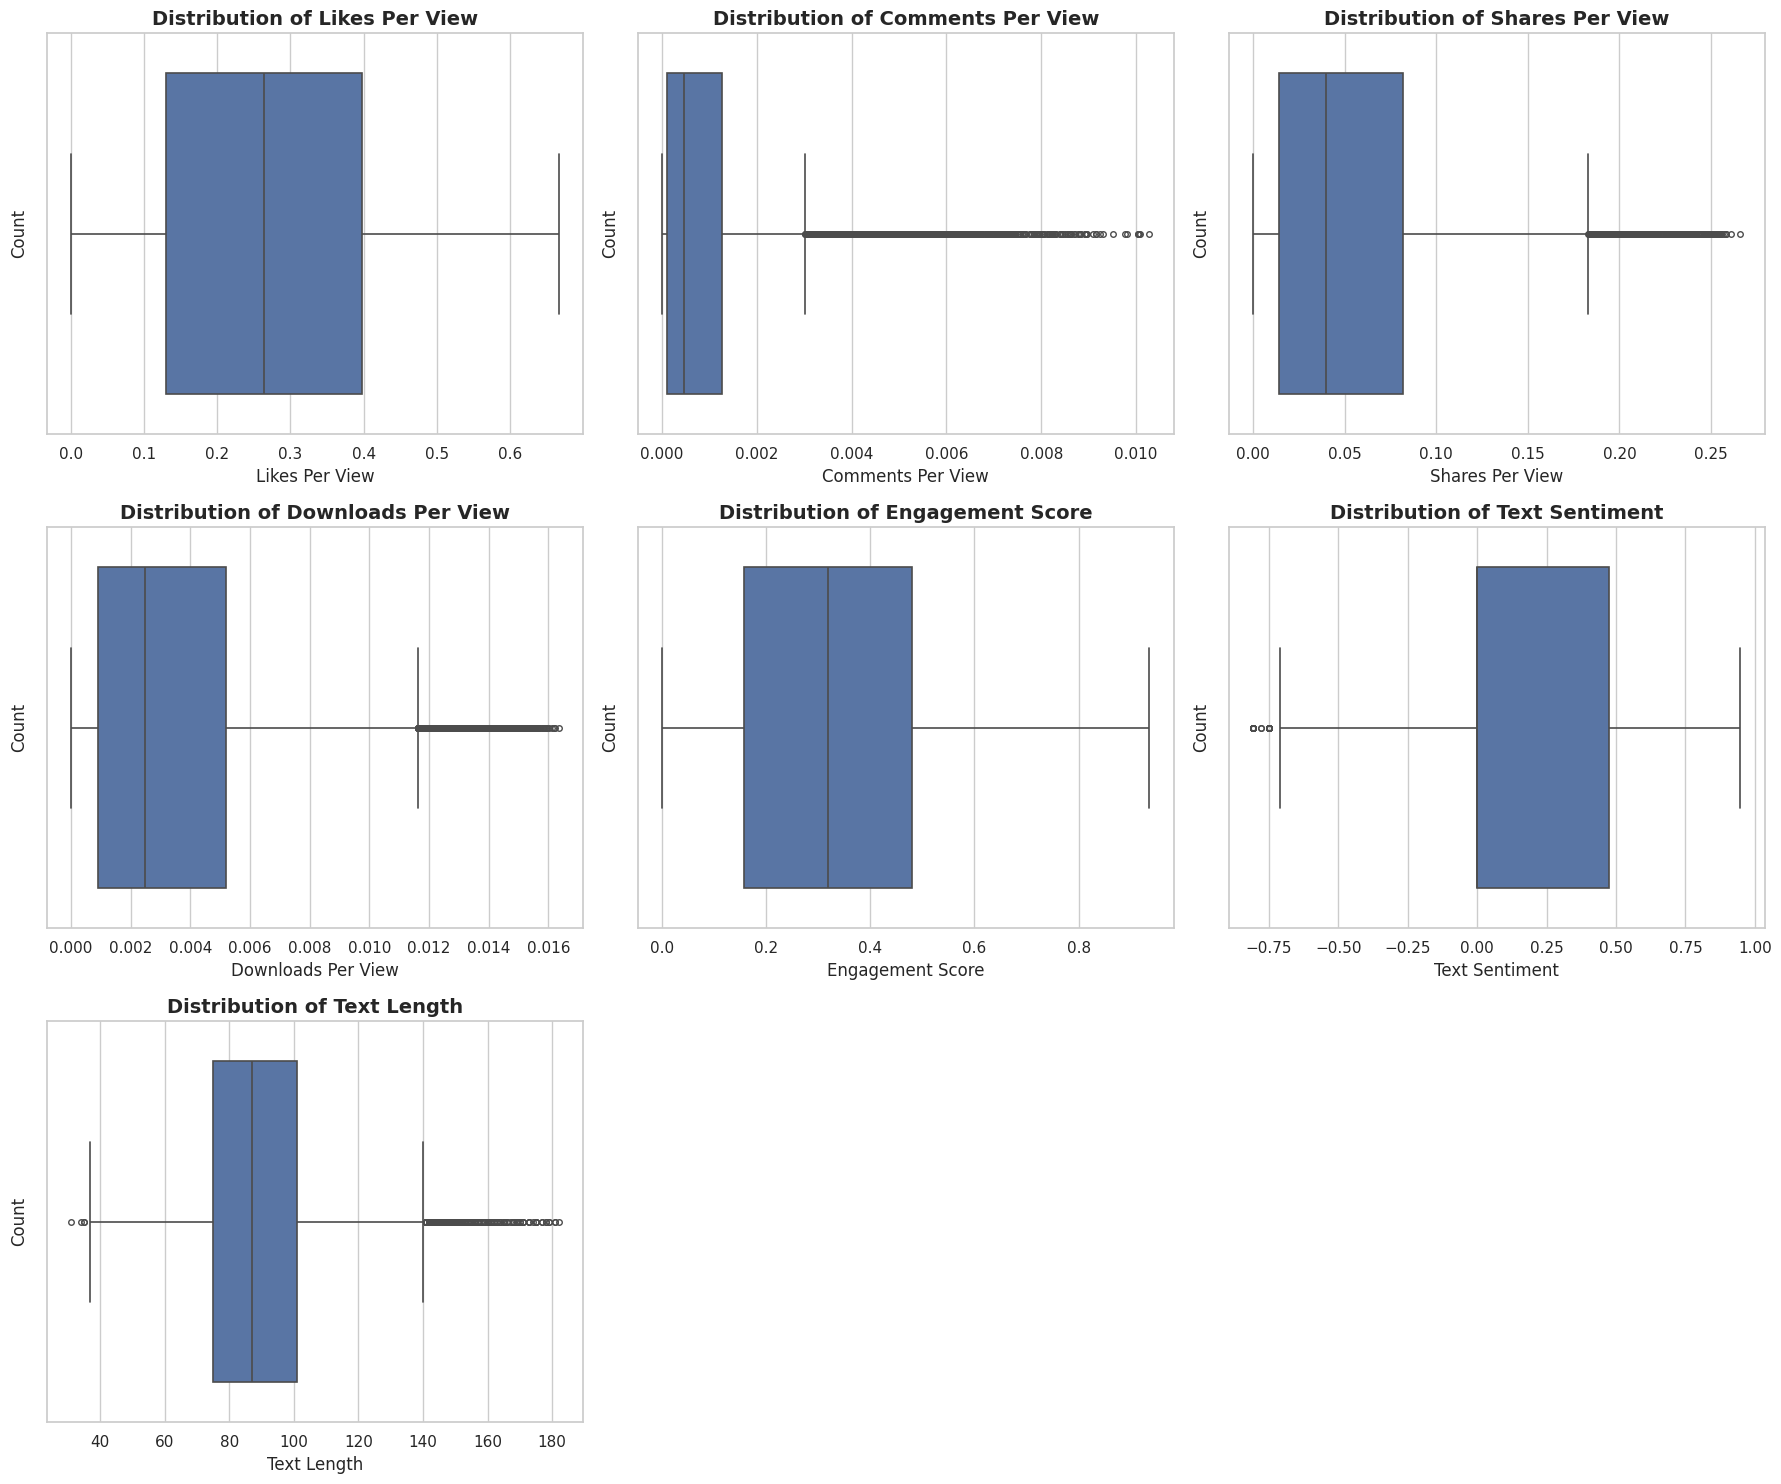

In [ ]:
# Create subplot grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

# Loop through numeric columns and create boxplots
for i, col in enumerate(num_col):
    sns.boxplot(
        x=df0[col],
        ax=axes[i],
        color="#4C72B0",
        fliersize=4,
        linewidth=1.2
    )
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=14, weight='bold')
    axes[i].set_xlabel(col.replace("_", " ").title(), fontsize=12)
    axes[i].set_ylabel("Count", fontsize=12)

# Remove empty subplots if num_col < nrows*ncols
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


#### Distribution Plot for Claim Status

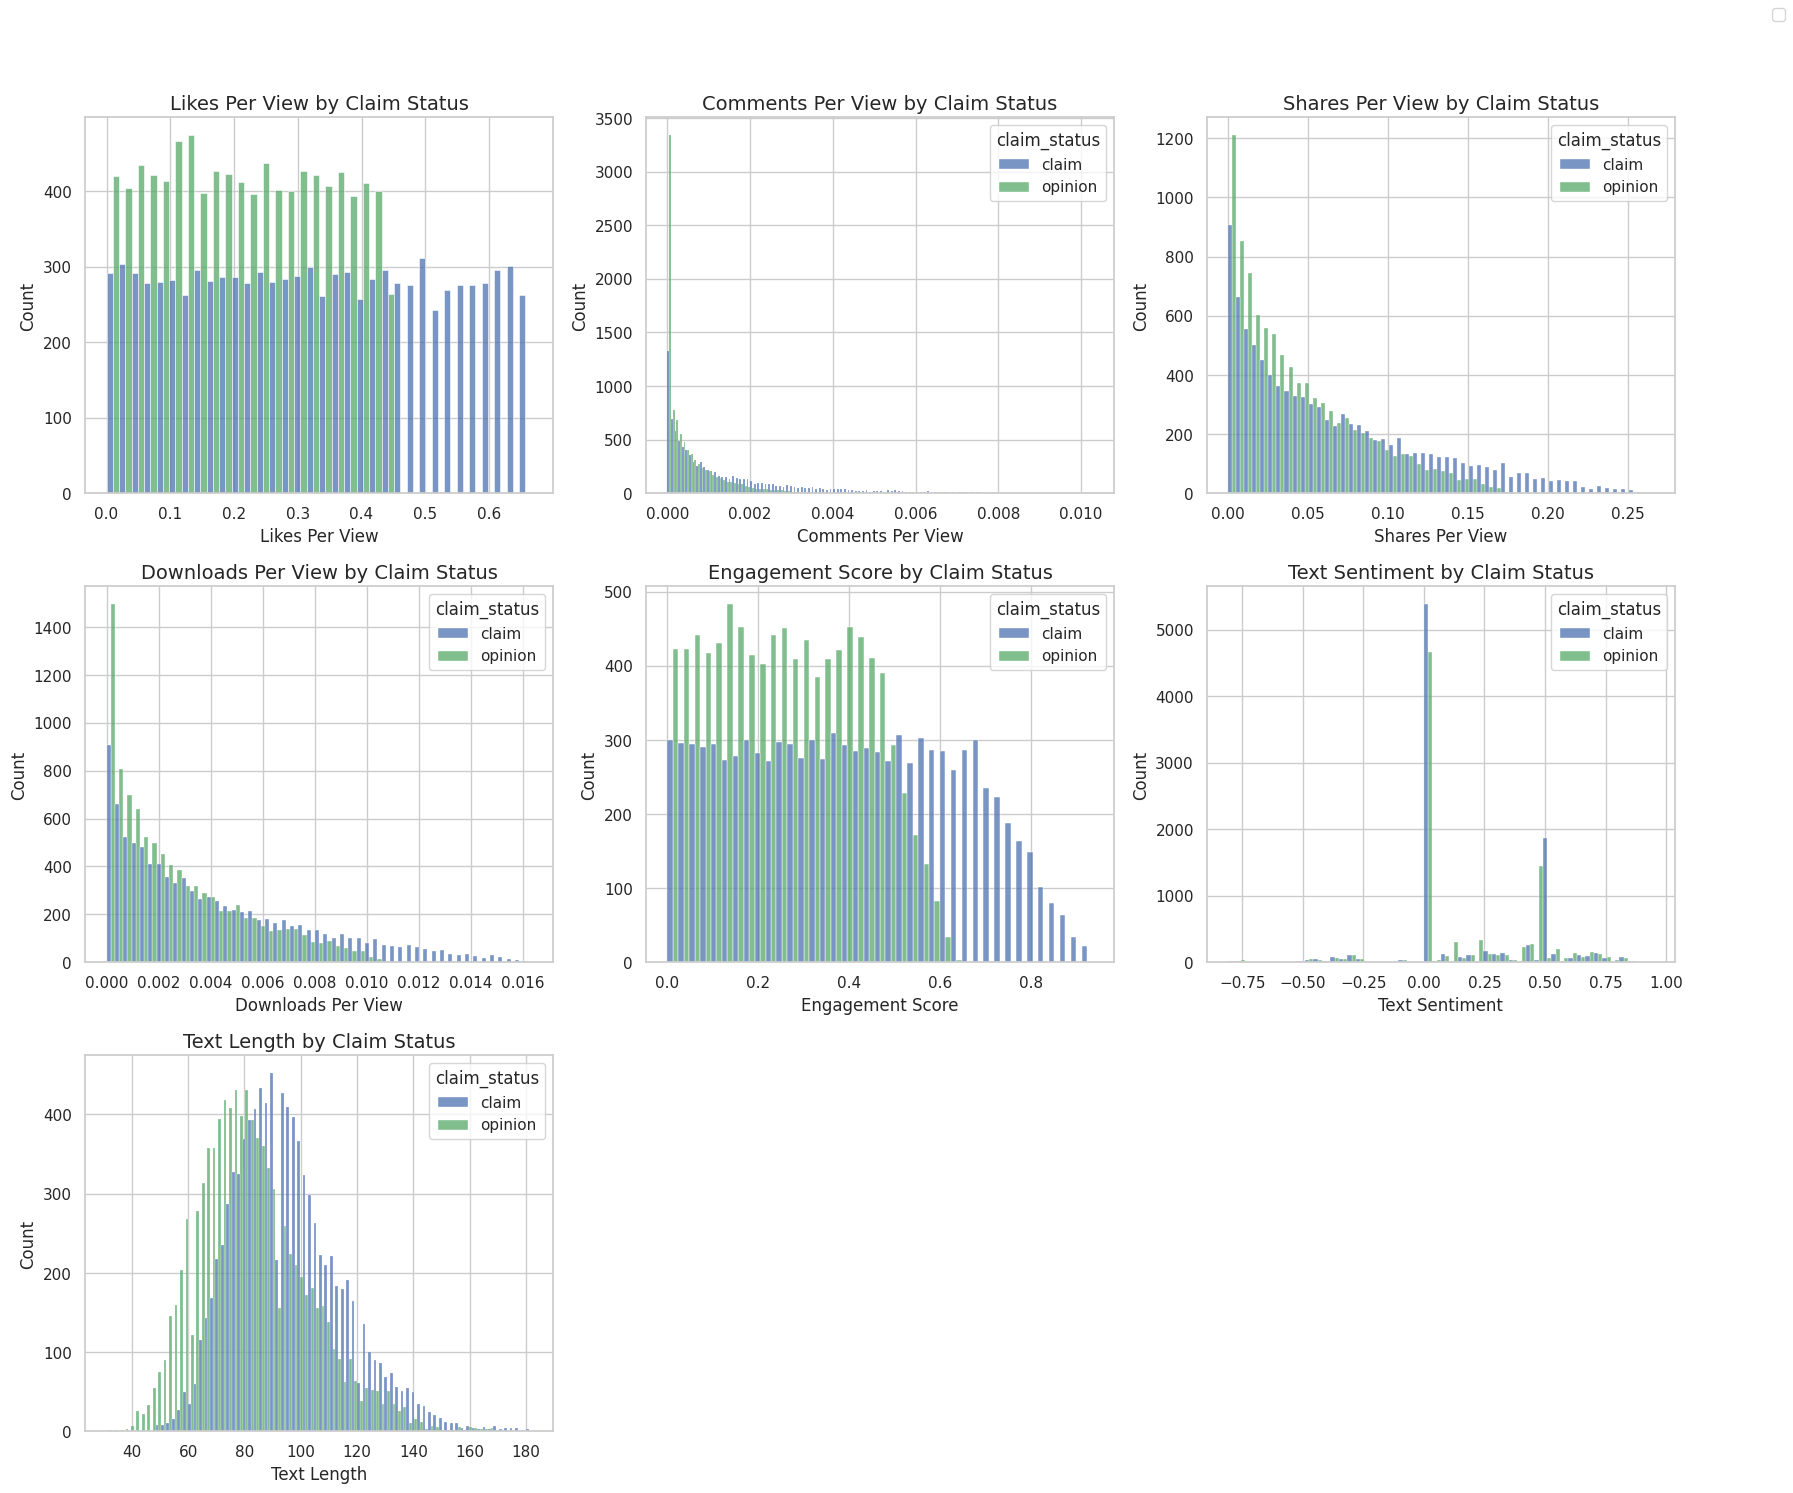

In [ ]:
# Professional seaborn style
sns.set_style("whitegrid")
palette = ["#4C72B0", "#55A868"]  # Claim vs Opinion colors

# Create figure with 2 rows and 3 columns
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Loop to plot each histogram
for i, col in enumerate(num_col):
    sns.histplot(
        data=df0,
        x=col,
        hue="claim_status",
        multiple="dodge",
        stat="count",
        kde=False,
        palette=palette,
        element="bars",
        ax=axes[i]
    )
    axes[i].set_xlabel(col.replace('_', ' ').title(), fontsize=12)
    axes[i].set_ylabel("Count", fontsize=12)
    axes[i].set_title(f"{col.replace('_', ' ').title()} by Claim Status", fontsize=14)

# Remove unused subplot if any
if len(num_col) < len(axes):
    for j in range(len(num_col), len(axes)):
        fig.delaxes(axes[j])

# Only show legend once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=12)
axes[0].get_legend().remove()  # remove legend from first subplot

plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()


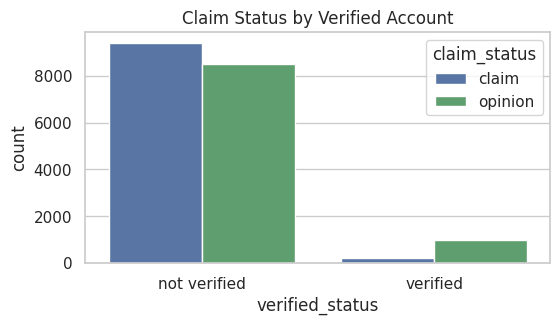

In [ ]:
plt.figure(figsize=(6,3))
sns.countplot(data=df0, x='verified_status', hue='claim_status', palette=palette)
plt.title("Claim Status by Verified Account")
plt.show()

#### Variable Encoding NOT YET COMPLETE

In [ ]:
df0['claim_status2'] = np.where((df0['claim_status'] == "opinion"), 0,1)
df0[['claim_status', 'claim_status2']].tail(5)

#### Outlier Handling

From the previous section, the boxplots indicated that many of these numerical variables contain clear outliers. Based on my analysis, these outliers do not appear to be data entry errors—they arise naturally from the right-skewed distributions of the variables.

Depending on how the data will be used, it may be useful to handle these extreme values to reduce their impact on modeling. One approach is to **impute outlying values with more reasonable thresholds, rather than removing them entirely**. A common technique is to set a threshold based on a specific percentile of the distribution.

A function that calculates the **95th percentile** for a given column and then replaces any value exceeding this percentile with the 95th percentile value itself will be used. This ensures that extreme values are capped while preserving the overall distribution structure.

However, for a tree based model, it is not necessary to impute this outliers. So a different dataframe will be used for Logistic Regression model and Tree-based model.

In [ ]:
def cap_outliers(df_input, columnname, percentile=0.95):
    """
    Caps values above a given percentile for a specified column in a DataFrame.

    Parameters:
    df_input (pd.DataFrame): The DataFrame to modify
    columnname (str): The column to cap
    percentile (float): The percentile threshold (default is 0.95)

    Returns:
    pd.DataFrame: DataFrame with capped column
    """
    p_val = round(df_input[columnname].quantile(percentile), 2)
    df_input[columnname] = df_input[columnname].where(df_input[columnname] < p_val, p_val)
    print(f"{columnname} capped at {int(percentile*100)}th percentile: {p_val}")
    return df_input

In this section we will create a separate dataframe `df_clean` where in we pass the function `cap_outliers` we have created earlier for outlier handling.

This `df_clean` will be used to model our `logistic regression` while `df` will be retained as is without outlier handling will be used for our `tree-based model`.

In [ ]:
df_clean = df0.copy()

In [ ]:
column_list = ['video_like_count',  'video_share_count', 'video_download_count',
               'video_comment_count', 'comments_per_view', 'shares_per_view']

for columnname in column_list:
    df_clean = cap_outliers(df_clean, columnname)

In [ ]:
df_clean.describe()

In [ ]:
df0.describe()

#### Evaluation Metric Selection

In [ ]:
# Get class balance of 'claim_status' col
df0['claim_status'].value_counts(normalize = True)

In [ ]:
df0.shape

### MODEL DEVELOPMENT

The final modeling dataset contains **19,084 videos**. While this dataset is relatively modest for complex machine learning tasks, it provides sufficient information to build meaningful predictive models and derive actionable insights for content moderation.  

To ensure a rigorous modeling approach, I implemented the following workflow:

1. **Data Partitioning (Train/Validation/Test)**  
   I split the dataset into **60/20/20** proportions, carefully maintaining representation of the **minority class (`claim` videos)**.  
   - With this split, the **validation and test sets each contain ~3,817 videos**, including approximately **1,922 claim instances (50%)**, ensuring a reliable basis for model evaluation and reducing sampling bias.  

2. **Model Training and Hyperparameter Optimization**  
   Candidate models—including Random Forest and XGBoost—were trained on the **training set**, with hyperparameters tuned to maximize **recall** and predictive performance while avoiding overfitting.  

3. **Model Selection Using Validation Set**  
   The **validation set** was used to compare candidate models and identify the **champion model** that best balances accuracy, recall, and generalizability.  

4. **Performance Assessment on Test Set**  
   Finally, the **champion model** was evaluated on the **test set** to confirm predictive power on unseen videos, ensuring the solution is robust and reliable for moderation decision-making.  

5. **Ethical Considerations and Metric Choice**  
   Since the primary goal is to mitigate misinformation, it is **more important to avoid false negatives** (i.e., failing to identify a claim that violates TikTok’s terms of service) than false positives.  
   - Therefore, **recall** was prioritized as the key evaluation metric, ensuring that most harmful content is flagged for review.  
   - This approach balances platform safety with fairness, minimizing the risk of harmful content slipping through while limiting unnecessary review of opinion videos.

This structured workflow ensures that the claim classification model is **statistically sound, ethically responsible, and actionable**, providing TikTok stakeholders with confidence in its ability to support efficient content review and mitigate misinformation.


![](https://raw.githubusercontent.com/adacert/tiktok/main/optimal_model_flow_numbered.svg)


#### Train, Validate, Test Split

In [ ]:
# Isolate X variables
X = df0.copy().drop(columns=['claim_status', 'video_transcription_text'])

# Isolate y variable
y = df0['claim_status2']

# Split into train and test sets
X_tr, X_test, y_tr, y_test = train_test_split(X, y, stratify=y,
                                              test_size=0.2, random_state=42)

# Split into train and validate sets
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, stratify=y_tr,
                                                  test_size=0.25, random_state=42)

In [ ]:
print(len(X_train), len(X_val), len(X_test))
print(len(y_train), len(y_val), len(y_test))

11450 3817 3817
11450 3817 3817


In [ ]:
print(y_val.value_counts(normalize = True))
print(y_test.value_counts())

claim_status2
1    0.503537
0    0.496463
Name: proportion, dtype: float64
claim_status2
1    1922
0    1895
Name: count, dtype: int64


In [ ]:
def get_test_scores(model_name:str, preds, y_test_data):
    '''
    Generate a table of test scores.

    In:
        model_name (string): Your choice: how the model will be named in the output table
        preds: numpy array of test predictions
        y_test_data: numpy array of y_test data

    Out:
        table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy]
                          })

    return table

In [ ]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy',
                   }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          },
                         )

    return table

#### Pipeline

In [ ]:
numeric_features = ['video_duration_sec', 'video_view_count',
                    'video_like_count', 'video_share_count',
                    'video_download_count', 'video_comment_count',
                    'likes_per_view', 'comments_per_view', 'shares_per_view',
                    'text_sentiment', 'text_length']
categorical_features = ['verified_status', 'author_ban_status']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])



#### Model Training

##### Random Forest

In [ ]:
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

cv_params = {
    'classifier__max_depth': [5, 10, None],
    'classifier__max_features': ['sqrt', 'log2', 1.0],
    'classifier__max_samples': [0.5, 1.0],
    'classifier__min_samples_leaf': [2, 4, 8],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__n_estimators': [300]
}

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='recall')
rf_cv.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['video_duration_sec',
                                                                          'video_view_count',
                                                                          'video_like_count',
                                                                          'video_share_count',
                                                                          'video_download_count',
                                                                          'video_comment_count',
                                                                          'likes_per_view',
                                                                          'comments_per_view',
                                                                          'shares_per_view',
                                                                          'text_sentiment',
                                                                          'text_length']),
                                                                        ('cat',
                                                                         OneHotEncoder(...
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [5, 10, None],
                         'classifier__max_features': ['sqrt', 'log2', 1.0],
                         'classifier__max_samples': [0.5, 1.0],
                         'classifier__min_samples_leaf': [2, 4, 8],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [300]},
             refit='recall',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'})

In [ ]:
print("Best Recall Score:", rf_cv.best_score_)
print("Best Hyperparameters:", rf_cv.best_params_)

Best Recall Score: 0.9953155114676691
Best Hyperparameters: {'classifier__max_depth': 5, 'classifier__max_features': 1.0, 'classifier__max_samples': 0.5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}


In [ ]:
results = make_results('RandomForest Train', rf_cv, 'recall')
results

,model,precision,recall,F1,accuracy
0,RandomForest Train,1.0,0.995316,0.997651,0.997642


##### XGBoost

In [ ]:
# 1. Instantiate the XGBoost classifier
xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42))])

# 2. Create a dictionary of hyperparameters to tune
xgb_params = {
    'classifier__max_depth': [6, 10, 15],
    'classifier__min_child_weight': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__n_estimators': [300, 500]
}


# 3. Define a list of scoring metrics to capture
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'}

# 4. Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, xgb_params, scoring = scoring, refit = 'recall', cv = 5)

# 5. Fit the model
xgb_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['video_duration_sec',
                                                                          'video_view_count',
                                                                          'video_like_count',
                                                                          'video_share_count',
                                                                          'video_download_count',
                                                                          'video_comment_count',
                                                                          'likes_per_view',
                                                                          'comments_per_view',
                                                                          'shares_per_view',
                                                                          'text_sentiment',
                                                                          'text_length']),
                                                                        ('cat',
                                                                         OneHotEncoder(...
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             param_grid={'classifier__learning_rate': [0.01, 0.1],
                         'classifier__max_depth': [6, 10, 15],
                         'classifier__min_child_weight': [3, 5, 7],
                         'classifier__n_estimators': [300, 500]},
             refit='recall',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'})

In [ ]:
print("Best Recall Score:", xgb_cv.best_score_)
print("Best Hyperparameters:", xgb_cv.best_params_)

Best Recall Score: 0.9947949792811025
Best Hyperparameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 10, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 300}


In [ ]:
xgb_result = make_results('XGBoost Train', xgb_cv, 'recall')
results = pd.concat([results, xgb_result], axis = 0)
results

,model,precision,recall,F1,accuracy
0,RandomForest Train,1.000000,0.995316,0.997651,0.997642
0,XGBoost Train,0.999651,0.994795,0.997216,0.997205


#### Validation

In [ ]:
# Use random forest model to predict on validation data
rf_val = rf_cv.best_estimator_.predict(X_val)

# Get validation scores for RF model
rf_val_results = get_test_scores('RandomForest Validation', rf_val, y_val)

# Append to the results table
results = pd.concat([results, rf_val_results], axis = 0)
results

,model,precision,recall,F1,accuracy
0,RandomForest Train,1.000000,0.995316,0.997651,0.997642
0,XGBoost Train,0.999651,0.994795,0.997216,0.997205
0,RandomForest Validation,1.000000,0.996878,0.998437,0.998428


In [ ]:
# Use XGBoost model to predict on validation data
xgb_val = xgb_cv.best_estimator_.predict(X_val)

# Get validation scores for XGBoost model
xgb_val_results = get_test_scores('XGBoost Validation', xgb_val, y_val)

# Append to the results table
results = pd.concat([results, xgb_val_results], axis = 0)
results

,model,precision,recall,F1,accuracy
0,RandomForest Train,1.000000,0.995316,0.997651,0.997642
0,XGBoost Train,0.999651,0.994795,0.997216,0.997205
0,RandomForest Validation,1.000000,0.996878,0.998437,0.998428
0,XGBoost Validation,0.999478,0.996878,0.998177,0.998166


#### Model Selection and Evaluation

##### Testing

In [ ]:
# Use random forest model to predict on validation data
rf_test = rf_cv.best_estimator_.predict(X_test)

# Get validation scores for RF model
rf_test_results = get_test_scores('RandomForest Test', rf_test, y_test)

# Append to the results table
results = pd.concat([results, rf_test_results], axis = 0)
results

,model,precision,recall,F1,accuracy
0,RandomForest Train,1.000000,0.995316,0.997651,0.997642
0,XGBoost Train,0.999651,0.994795,0.997216,0.997205
0,RandomForest Validation,1.000000,0.996878,0.998437,0.998428
0,XGBoost Validation,0.999478,0.996878,0.998177,0.998166
0,RandomForest Test,1.000000,0.995838,0.997914,0.997904


##### Confusion Matrix

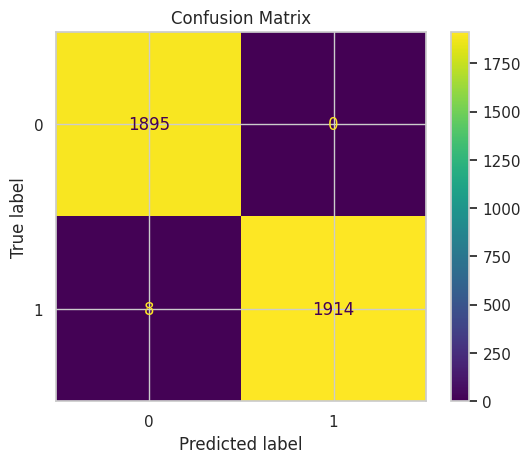

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, rf_test)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_cv.best_estimator_.classes_)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

Feature Importance

In [ ]:
# 1. Get the trained RandomForest from inside the pipeline
best_rf_clf = best_rf.named_steps['classifier']

# 2. Extract feature importances
importances = best_rf_clf.feature_importances_

# 3. Get feature names from preprocessor
num_features = numeric_features

cat_features = best_rf.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .get_feature_names_out(categorical_features)

text_features = best_rf.named_steps['preprocessor'] \
    .named_transformers_['text'] \
    .get_feature_names_out()

# Combine all feature names
all_features = np.concatenate([num_features, cat_features, text_features])

# 4. Create DataFrame
feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# 5. Plot top 15
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance_df.head(15)['feature'][::-1],
    feature_importance_df.head(15)['importance'][::-1],
    color='skyblue'
)
plt.xlabel("Feature Importance")
plt.title("Feature Importances - Random Forest")
plt.show()



NameError: name 'best_rf' is not defined

In [ ]:
# Get the best trained Random Forest from GridSearchCV
best_rf = rf_cv.best_estimator_

# Extract feature importances
importances = best_rf.feature_importances_

# Create a DataFrame with feature names and importances
feature_importance_df = pd.DataFrame({
    'feature': X_train_res.columns,
    'importance': importances
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Plot the top 15 features
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance_df['feature'][:][::-1],
    feature_importance_df['importance'][:][::-1],
    color='skyblue'
)
plt.xlabel("Feature Importance")
plt.title("Feature Importances - Random Forest")
plt.show()

AttributeError: 'Pipeline' object has no attribute 'feature_importances_'

In [ ]:
# Get the Random Forest model from the pipeline
rf_model = best_rf.named_steps['classifier']  # use the name of the step in your pipeline

# Extract feature importances
importances = rf_model.feature_importances_

# Create a DataFrame with feature names and importances
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Plot the top 15 features
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance_df['feature'][:15][::-1],
    feature_importance_df['importance'][:15][::-1],
    color='skyblue'
)
plt.xlabel("Feature Importance")
plt.title("Feature Importances - Random Forest")
plt.show()


ValueError: All arrays must be of the same length

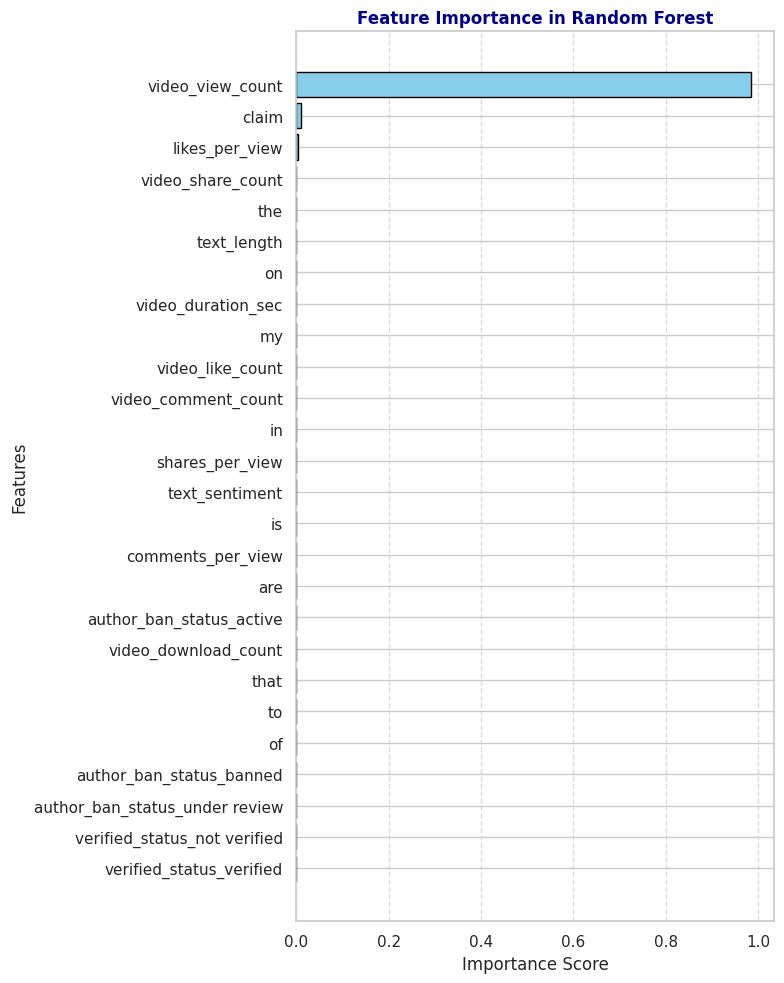

In [ ]:
# Access preprocessed feature names
preprocessed_features = rf_cv.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

# Remove prefixes added by ColumnTransformer
cleaned_features = [name.split('__')[-1] for name in preprocessed_features]  # Extract the actual feature names

# Get feature importances
best_rf_model = rf_cv.best_estimator_.named_steps['classifier']
feature_importances = best_rf_model.feature_importances_

# Create DataFrame for organization
importance_df = pd.DataFrame({'Feature': cleaned_features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(8, 10))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance in Random Forest', fontsize=12, fontweight='bold', color='darkblue')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### CONCLUSION AND RECOMMENDATION